<h1>EXERCISE 1</h1>

<h1>🔹 Data Exploration</h1>
<h3>This section explores the dataset, identifying missing values and potential data quality issues, and outlines strategies for handling them.</h3>

In [3]:
# --- Load Dataset ---
df = pd.read_csv("car_sales_data.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50000, 7)


,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


In [4]:
# Check for missing values
df.isnull().sum().to_frame("Missing Values")

# Basic statistics
print(df.describe())

# Check categorical features
print(df.dtypes)

# Unique values in categorical columns
print("Manufacturers:", df['Manufacturer'].nunique())
print("Models:", df['Model'].nunique())
print("Fuel types:", df['Fuel type'].unique())

        Engine size  Year of manufacture        Mileage          Price
count  50000.000000         50000.000000   50000.000000   50000.000000
mean       1.773058          2004.209440  112497.320700   13828.903160
std        0.734108             9.645965   71632.515602   16416.681336
min        1.000000          1984.000000     630.000000      76.000000
25%        1.400000          1996.000000   54352.250000    3060.750000
50%        1.600000          2004.000000  100987.500000    7971.500000
75%        2.000000          2012.000000  158601.000000   19026.500000
max        5.000000          2022.000000  453537.000000  168081.000000
Manufacturer            object
Model                   object
Engine size            float64
Fuel type               object
Year of manufacture      int64
Mileage                  int64
Price                    int64
dtype: object
Manufacturers: 5
Models: 15
Fuel types: ['Petrol' 'Diesel' 'Hybrid']


<h1>🔹 Visual Exploration</h1>
<h3>This section presents visualizations to identify trends, distributions, and potential predictive relationships in the dataset.</h3>

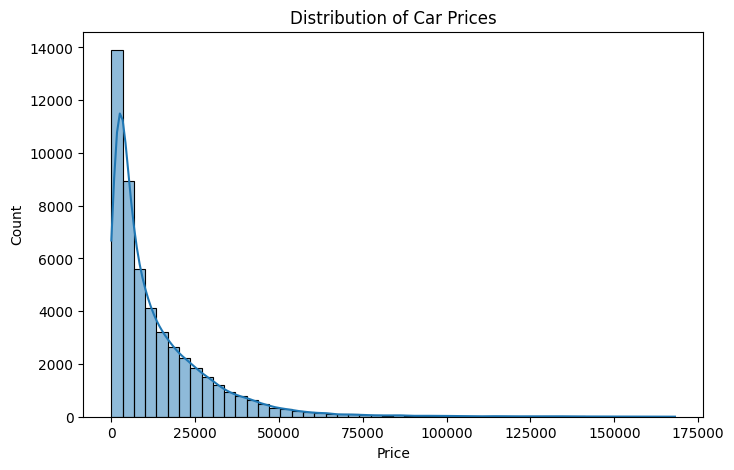

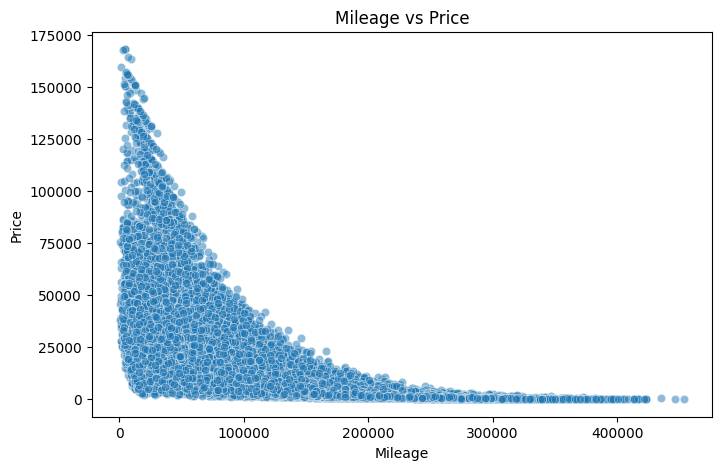

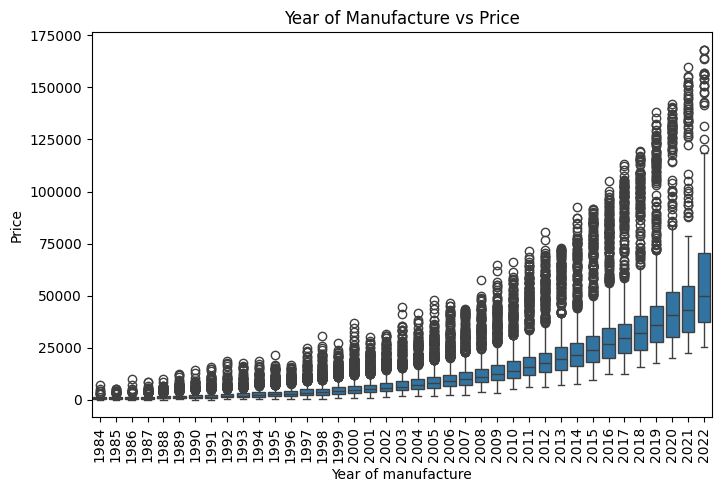

In [9]:
# Distribution of car prices
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title("Distribution of Car Prices")
plt.show()

# Mileage vs Price
plt.figure(figsize=(8,5))
sns.scatterplot(x='Mileage', y='Price', data=df, alpha=0.5)
plt.title("Mileage vs Price")
plt.show()

# Year vs Price
plt.figure(figsize=(8,5))
sns.boxplot(x='Year of manufacture', y='Price', data=df)
plt.xticks(rotation=90)
plt.title("Year of Manufacture vs Price")
plt.show()

<h1>🔹 Data Preprocessing</h1>
<h3>In this section, I will encode the data, create a copy of the original dataset, and apply standardization techniques such as mean-centering and scaling based on standard deviation.</h3>

In [10]:
# Encode categorical variables
df_encoded = df.copy()

# Label encode fuel type
le = LabelEncoder()
df_encoded['Fuel type'] = le.fit_transform(df_encoded['Fuel type'])

# One-hot encode manufacturer and model (to use later in regression/ANN)
df_encoded = pd.get_dummies(df_encoded, columns=['Manufacturer','Model'], drop_first=True)

# Feature scaling (for ANN & clustering later)
scaler = StandardScaler()
num_features = ['Engine size', 'Year of manufacture', 'Mileage', 'Price']
df_encoded[num_features] = scaler.fit_transform(df_encoded[num_features])

df_encoded.head()


,Engine size,Fuel type,Year of manufacture,Mileage,Price,Manufacturer_Ford,Manufacturer_Porsche,Manufacturer_Toyota,Manufacturer_VW,Model_911,...,Model_Golf,Model_M5,Model_Mondeo,Model_Passat,Model_Polo,Model_Prius,Model_RAV4,Model_X3,Model_Yaris,Model_Z4
0,-1.053068,2,-0.229056,0.206650,-0.655127,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,3.033566,2,1.222343,-0.762892,2.185305,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,-0.235742,0,1.015000,-1.023391,0.623951,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,0.036701,1,-1.680454,1.372528,-0.738519,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4,-1.053068,2,0.185630,0.214593,-0.592568,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


<h2>Step 1: Single-Variable Regression Models.</h2>
<h3>The goal here is to see which numerical feature (Engine size, Year, or Mileage) is the best predictor of car price.</h3>

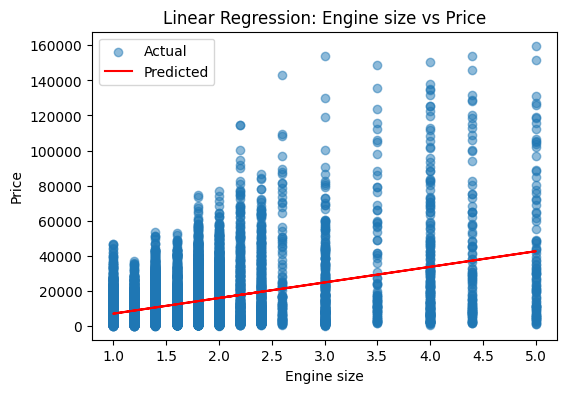

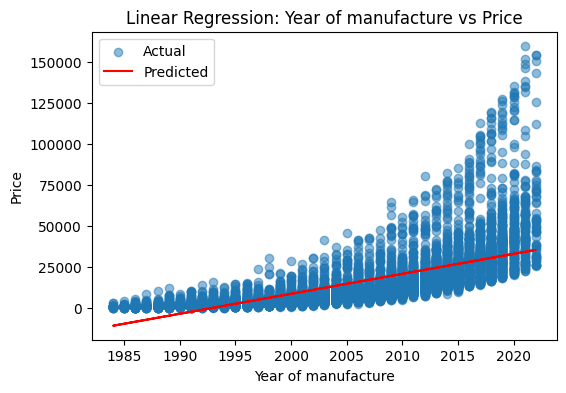

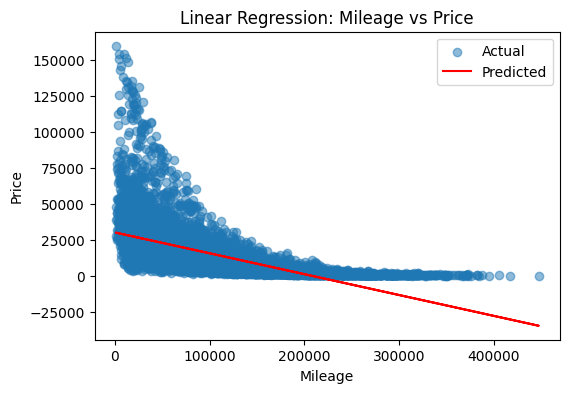

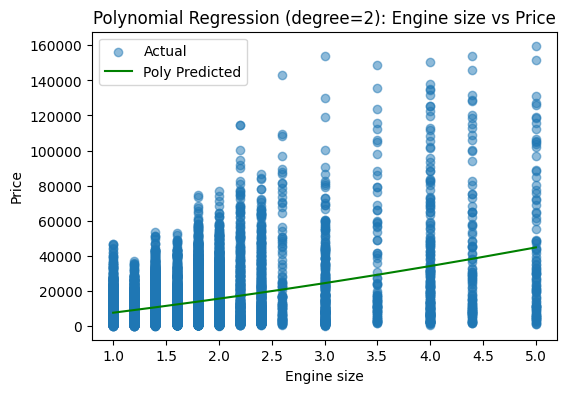

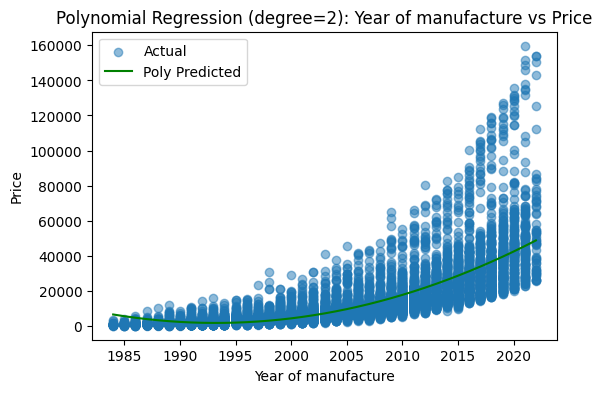

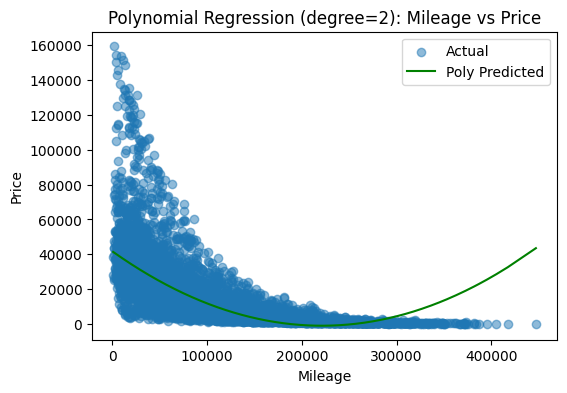

                       Linear MSE  Linear R2      Poly MSE   Poly R2
Engine size          2.304992e+08   0.150626  2.303262e+08  0.151263
Year of manufacture  1.326790e+08   0.511087  1.059939e+08  0.609419
Mileage              1.624686e+08   0.401314  1.296203e+08  0.522358


In [19]:
#1️⃣ Define features and target
# Use the original numerical columns (not scaled) for interpretability
features = ['Engine size', 'Year of manufacture', 'Mileage']
target = 'Price'

X = df[features]
y = df[target]

#2️⃣ Train/Test split
# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Store results ---
results = {}

#3️⃣ Linear Regression for each feature
for feature in features:
    lr = LinearRegression()
    
    # Keep feature as DataFrame
    X_train_feat = X_train[[feature]].copy()
    X_test_feat = X_test[[feature]].copy()
    
    # Train model & Predict
    lr.fit(X_train_feat, y_train)
    y_pred = lr.predict(X_test_feat)
    
    # Evaluation
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[feature] = {'Linear MSE': mse, 'Linear R2': r2}
    
    # Plot linear regression
    plt.figure(figsize=(6,4))
    plt.scatter(X_test_feat, y_test, alpha=0.5, label='Actual')
    plt.plot(X_test_feat, y_pred, color='red', label='Predicted')
    plt.title(f'Linear Regression: {feature} vs Price')
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.legend()
    plt.show()
    

#4️⃣ Polynomial Regression (degree=2) for each feature
for feature in features:
    # Extract as 2D NumPy array
    X_train_feat = X_train[[feature]].values
    X_test_feat = X_test[[feature]].values
    
    poly = PolynomialFeatures(degree=2)
    X_train_poly = poly.fit_transform(X_train_feat)
    X_test_poly = poly.transform(X_test_feat)
    
    lr = LinearRegression()
    lr.fit(X_train_poly, y_train)
    y_pred_poly = lr.predict(X_test_poly)
    
    mse = mean_squared_error(y_test, y_pred_poly)
    r2 = r2_score(y_test, y_pred_poly)
    
    results[feature].update({'Poly MSE': mse, 'Poly R2': r2})
    
    # Plot polynomial regression
    plt.figure(figsize=(6,4))
    plt.scatter(X_test_feat, y_test, alpha=0.5, label='Actual')
    
    # Smooth curve
    X_plot = np.sort(X_test_feat, axis=0)
    X_plot_poly = poly.transform(X_plot)
    y_plot = lr.predict(X_plot_poly)
    
    plt.plot(X_plot, y_plot, color='green', label='Poly Predicted')
    plt.title(f'Polynomial Regression (degree=2): {feature} vs Price')
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.legend()
    plt.show()

# --- Compare results ---
results_df = pd.DataFrame(results).T
print(results_df)

<h1>Step 1b: Multi-variable regression.</h1>
<h3>Here, instead of predicting Price from just one numerical feature, we’ll use all numerical features together (Engine size, Year of manufacture, Mileage).</h3>

In [20]:
# Select multiple numerical features
X_multi = df[['Engine size', 'Year of manufacture', 'Mileage']]
y = df['Price']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Train Linear Regression model
multi_lin_reg = LinearRegression()
multi_lin_reg.fit(X_train, y_train)

# Predictions
y_pred_multi = multi_lin_reg.predict(X_test)

# Evaluation metrics
mse_multi = mean_squared_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("📊 Multiple Linear Regression Results:")
print("Mean Squared Error (MSE):", mse_multi)
print("R-squared (R²):", r2_multi)

# Compare coefficients
coefficients = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': multi_lin_reg.coef_
})
print("\nFeature Coefficients:")
print(coefficients)

📊 Multiple Linear Regression Results:
Mean Squared Error (MSE): 89158615.7601719
R-squared (R²): 0.6714563064173662

Feature Coefficients:
               Feature  Coefficient
0          Engine size  8931.978776
1  Year of manufacture   987.317147
2              Mileage    -0.038014


<h1> Step 1c: Random Forest Regression with categorical + numerical variables</h1>
<h3>The task here is to train a regression model (e.g. Random Forest Regressor) that uses all available features (numerical + categorical) and check whether this improves prediction accuracy.</h3>

In [23]:
# Copy dataset just a safety step so that if the one-hot encoding changed column structures, it wouldn’t affect the original df.
df_rf = df.copy()

# One-hot encode categorical variables
df_rf = pd.get_dummies(df_rf, columns=['Manufacturer', 'Model', 'Fuel type'], drop_first=True)

# Define features (all except Price)
X_all = df_rf.drop('Price', axis=1)
y_all = df_rf['Price']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

# Train Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_reg.predict(X_test)

# Evaluation metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("🌳 Random Forest Regression Results:")
print("Mean Squared Error (MSE):", mse_rf)
print("R-squared (R²):", r2_rf)

# Feature importance
importances = pd.DataFrame({
    'Feature': X_all.columns,
    'Importance': rf_reg.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:")
print(importances.head(10))

🌳 Random Forest Regression Results:
Mean Squared Error (MSE): 415044.78318214
R-squared (R²): 0.9984705869992906

Top 10 Important Features:
                 Feature  Importance
1    Year of manufacture    0.618753
0            Engine size    0.260182
2                Mileage    0.039910
7              Model_911    0.021236
12              Model_M5    0.020695
22      Fuel type_Petrol    0.009508
17            Model_RAV4    0.008732
4   Manufacturer_Porsche    0.005002
6        Manufacturer_VW    0.001841
5    Manufacturer_Toyota    0.001817


<h1>Step 1d: ANN Model for predicting car price</h1>
<h3>I will be building a simple Artificial Neural Network (ANN) using TensorFlow/Keras that takes all features (numerical + categorical) and predicts Price.</h3>

Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - loss: 259903808.0000 - mae: 9059.8467 - val_loss: 66980604.0000 - val_mae: 4515.0024
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 52680132.0000 - mae: 3792.5918 - val_loss: 33024232.0000 - val_mae: 2993.7527
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 35059336.0000 - mae: 3109.1677 - val_loss: 24542476.0000 - val_mae: 2598.9192
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 27998642.0000 - mae: 2787.2720 - val_loss: 19668592.0000 - val_mae: 2217.3276
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 23777730.0000 - mae: 2477.1169 - val_loss: 16038324.0000 - val_mae: 1924.2581
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 21569736.0000 - mae: 2263.0762 - val_loss: 13160048.0000 - val_mae: 1580.5911
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 18432516.0000 - mae: 2039.9081 - val_loss: 11009543.0000 - val_mae: 1344.8844
Epoch 8/50
1000

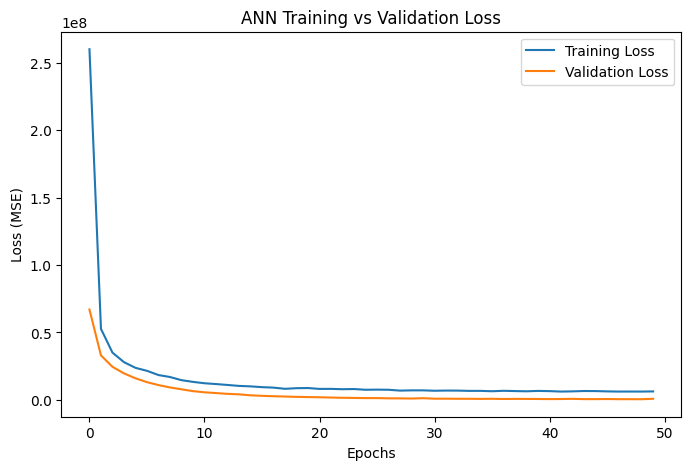

In [37]:
# --- Scale features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# --- Build ANN model ---
ann_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')  # regression output
])

ann_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# --- Train the ANN ---
history = ann_model.fit(
    X_train, y_train,
    epochs=50,              # adjust if needed
    batch_size=32,
    validation_split=0.2,   # keeps aside part of training data for validation
    verbose=1
)

# --- Evaluate on test data ---
y_pred_ann = ann_model.predict(X_test).flatten()

# Metrics
ann_mse = mean_squared_error(y_test, y_pred_ann)
ann_mae = mean_absolute_error(y_test, y_pred_ann)
ann_r2 = r2_score(y_test, y_pred_ann)

print("\n📊 Artificial Neural Network Results:")
print(f"Mean Squared Error (MSE): {ann_mse:.2f}")
print(f"Mean Absolute Error (MAE): {ann_mae:.2f}")
print(f"R-squared (R²): {ann_r2:.4f}")

# --- Plot training history ---
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("ANN Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

<h1>Step 1e: Use k-Means clustering on the dataset</h1>
<h3>I will write a code that automatically loops through all three feature combinations, finds the optimal k based on Silhouette Score, and plots the clusters:</h3>


--- Features: ['Engine size', 'Mileage'] ---
Optimal number of clusters (k): 3
Silhouette scores: {2: 0.3878223286907194, 3: 0.45001482759406836, 4: 0.3563656486835079, 5: 0.3581311178891045, 6: 0.3698661058480611, 7: 0.3679444915219572, 8: 0.3610182240125997, 9: 0.36663308640249276, 10: 0.3680518896034044}


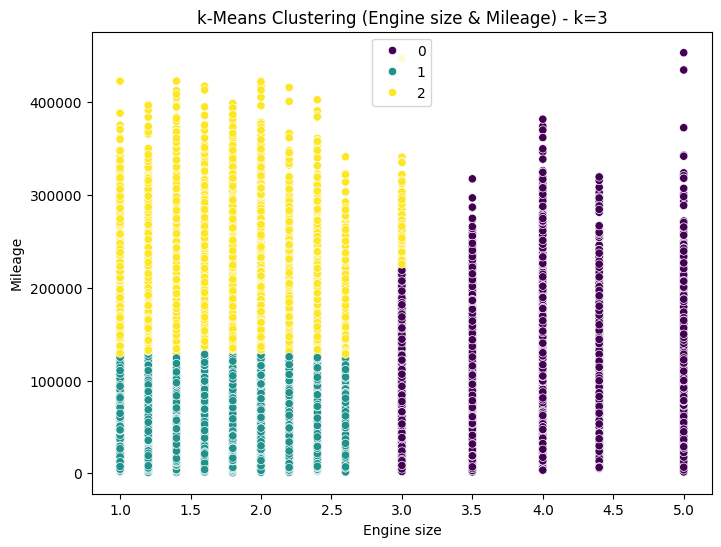


--- Features: ['Year of manufacture', 'Mileage'] ---
Optimal number of clusters (k): 2
Silhouette scores: {2: 0.5334431404238144, 3: 0.46483704685570876, 4: 0.4203441232113435, 5: 0.3805692467996414, 6: 0.39654551789499637, 7: 0.37374978205119097, 8: 0.3756497765925141, 9: 0.364244939436374, 10: 0.3583913625525993}


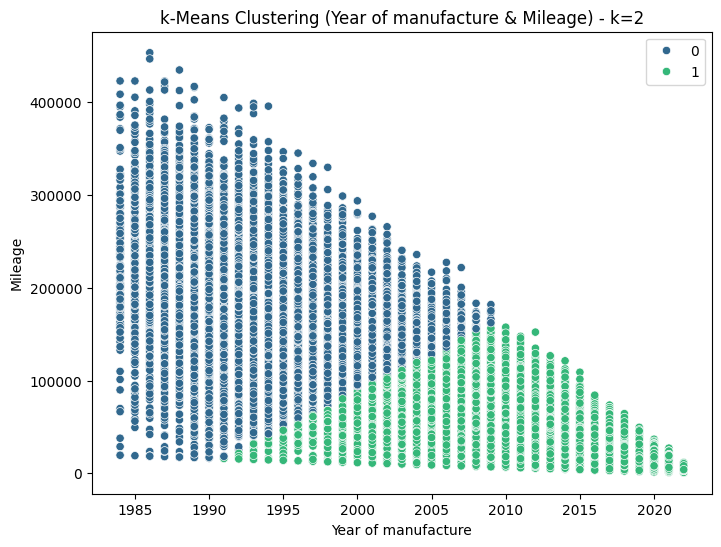


--- Features: ['Engine size', 'Year of manufacture', 'Mileage'] ---
Optimal number of clusters (k): 3
Silhouette scores: {2: 0.40288593787867844, 3: 0.4404523377422448, 4: 0.3515602336323234, 5: 0.28854385045787245, 6: 0.27463143344296603, 7: 0.29644458949819485, 8: 0.284949602059776, 9: 0.28412139060572583, 10: 0.28560537383321505}

Best feature combination: Year of manufacture_Mileage with silhouette score 0.5334


In [39]:
# List of feature combinations to test
feature_combinations = [
    ['Engine size', 'Mileage'],
    ['Year of manufacture', 'Mileage'],
    ['Engine size', 'Year of manufacture', 'Mileage']
]

# Dictionary to store results
cluster_results = {}

for features in feature_combinations:
    print(f"\n--- Features: {features} ---")
    
    # Prepare and scale data
    X_cluster = df[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)
    
    # Find optimal k using silhouette score
    sil_scores = {}
    for k in range(2, 11):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        score = silhouette_score(X_scaled, kmeans.labels_)
        sil_scores[k] = score
    
    # Best k
    best_k = max(sil_scores, key=sil_scores.get)
    print(f"Optimal number of clusters (k): {best_k}")
    print("Silhouette scores:", sil_scores)
    
    # Fit k-Means with best k
    kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels = kmeans_best.fit_predict(X_scaled)
    df[f'Cluster_{"_".join(features)}'] = labels
    
    # Save results
    cluster_results["_".join(features)] = {'k': best_k, 'score': sil_scores[best_k]}
    
    # Plot clusters (only works nicely for 2D)
    if len(features) == 2:
        plt.figure(figsize=(8,6))
        sns.scatterplot(x=df[features[0]], y=df[features[1]], hue=labels, palette='viridis')
        plt.title(f'k-Means Clustering ({features[0]} & {features[1]}) - k={best_k}')
        plt.show()

# Compare which combination gave the best silhouette score
best_combination = max(cluster_results, key=lambda x: cluster_results[x]['score'])
print(f"\nBest feature combination: {best_combination} with silhouette score {cluster_results[best_combination]['score']:.4f}")

<h1>Step 1f: compare k-Means to at least one other clustering algorithm.</h1>
<h3>I will be making use of Agglomerative Hierarchical Clustering. It’s easy to implement and gives a good contrast to k-Means.</h3>

In [ ]:
#Note: This is initially the code wriiten to compare the algorithms but due to the code being too heavy i wont be getting the result but i left it here in case your system can run it, it works 
# Use the best feature combination from k-Means
features = best_combination.split('_')
X_cluster = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Dendrogram (optional, for visualizing cluster distances)
plt.figure(figsize=(10, 5))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Euclidean distance')
plt.show()

# Fit Agglomerative Clustering with same number of clusters as k-Means
agglo = AgglomerativeClustering(n_clusters=cluster_results[best_combination]['k'])
labels_agglo = agglo.fit_predict(X_scaled)

# Silhouette Score
agglo_score = silhouette_score(X_scaled, labels_agglo)
print(f"Agglomerative Clustering Silhouette Score: {agglo_score:.4f}")

# Plot clusters if 2D
if len(features) == 2:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=df[features[0]], y=df[features[1]], hue=labels_agglo, palette='Set2')
    plt.title(f'Agglomerative Clustering ({features[0]} & {features[1]})')
    plt.show()


--- Features: ['Engine size', 'Mileage'] ---
Optimal k: 3, Silhouette Score: 0.4449


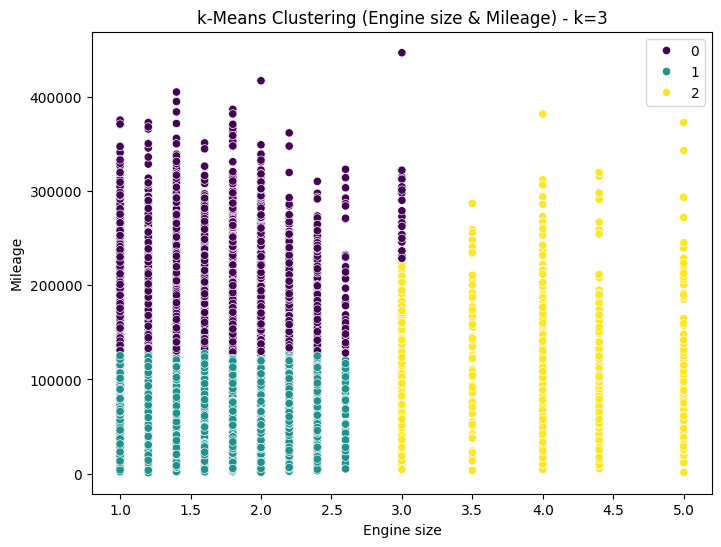


--- Features: ['Year of manufacture', 'Mileage'] ---
Optimal k: 2, Silhouette Score: 0.5326


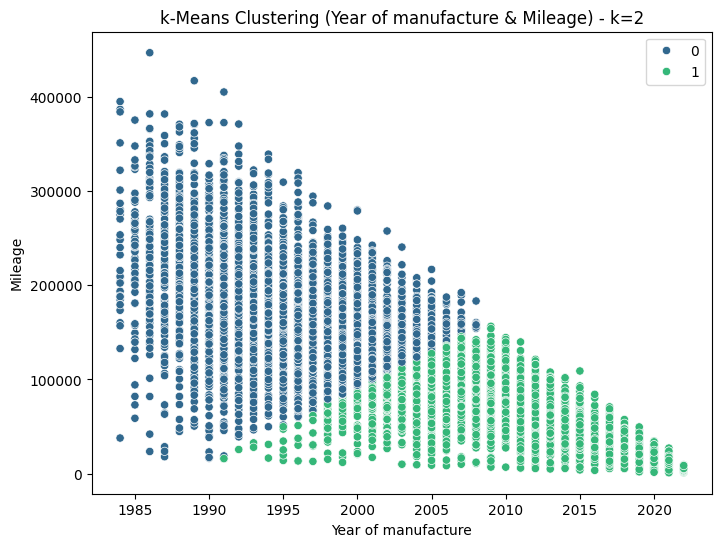


--- Features: ['Engine size', 'Year of manufacture', 'Mileage'] ---
Optimal k: 3, Silhouette Score: 0.4388

Agglomerative Clustering Silhouette Score: 0.4999


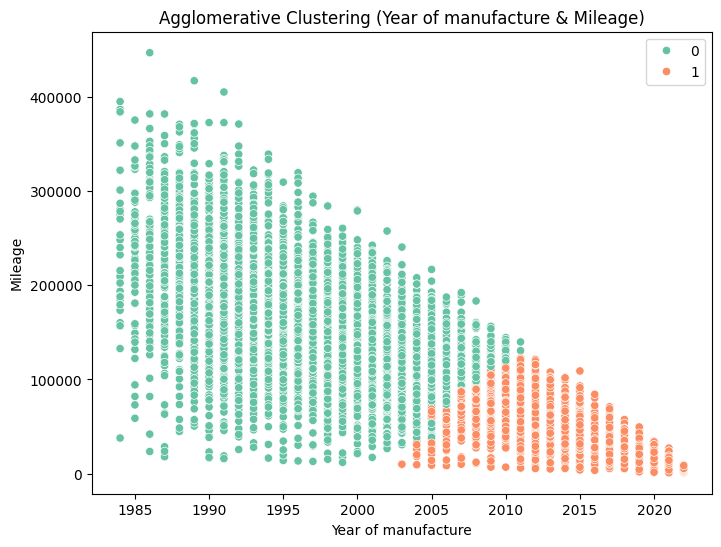

In [6]:
#NOTE: This is the code i used since the original is too heavy to run i cut down the number of rows it should work on so it releases the load 
df = pd.read_csv("car_sales_data.csv")
# --- 1️⃣ Sample dataset for clustering ---
df_sample = df.sample(n=10000, random_state=42)  # 10k rows

# --- 2️⃣ Feature combinations ---
feature_combinations = [
    ['Engine size', 'Mileage'],
    ['Year of manufacture', 'Mileage'],
    ['Engine size', 'Year of manufacture', 'Mileage']
]

cluster_results = {}

for features in feature_combinations:
    print(f"\n--- Features: {features} ---")
    
    # Scale features
    X_cluster = df_sample[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)
    
    # Find optimal k using silhouette score (k=2 to 6 only for speed)
    sil_scores = {}
    for k in range(2, 7):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        score = silhouette_score(X_scaled, kmeans.labels_)
        sil_scores[k] = score
    
    best_k = max(sil_scores, key=sil_scores.get)
    print(f"Optimal k: {best_k}, Silhouette Score: {sil_scores[best_k]:.4f}")
    
    # Fit k-Means with best k
    kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels_kmeans = kmeans_best.fit_predict(X_scaled)
    
    # Plot clusters (only for 2D)
    if len(features) == 2:
        plt.figure(figsize=(8,6))
        sns.scatterplot(x=df_sample[features[0]], y=df_sample[features[1]], hue=labels_kmeans, palette='viridis')
        plt.title(f'k-Means Clustering ({features[0]} & {features[1]}) - k={best_k}')
        plt.show()
    
    cluster_results["_".join(features)] = {'k': best_k, 'score': sil_scores[best_k], 'labels': labels_kmeans}

# --- 3️⃣ Agglomerative Clustering on best combination ---
best_combination = max(cluster_results, key=lambda x: cluster_results[x]['score'])
features = best_combination.split('_')
X_best = df_sample[features].copy()
X_scaled = StandardScaler().fit_transform(X_best)

agglo = AgglomerativeClustering(n_clusters=cluster_results[best_combination]['k'])
labels_agglo = agglo.fit_predict(X_scaled)

# Silhouette Score
agglo_score = silhouette_score(X_scaled, labels_agglo)
print(f"\nAgglomerative Clustering Silhouette Score: {agglo_score:.4f}")

# Plot clusters if 2D
if len(features) == 2:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=df_sample[features[0]], y=df_sample[features[1]], hue=labels_agglo, palette='Set2')
    plt.title(f'Agglomerative Clustering ({features[0]} & {features[1]})')
    plt.show()